<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
              Mean :    Median :  Std Dev :      IQR :
LB        133.340204  133.340204  11.214379  14.000000
AC          0.003204    0.003204   0.004373   0.005606
FM          0.009894    0.009894   0.067540   0.002567
UC    

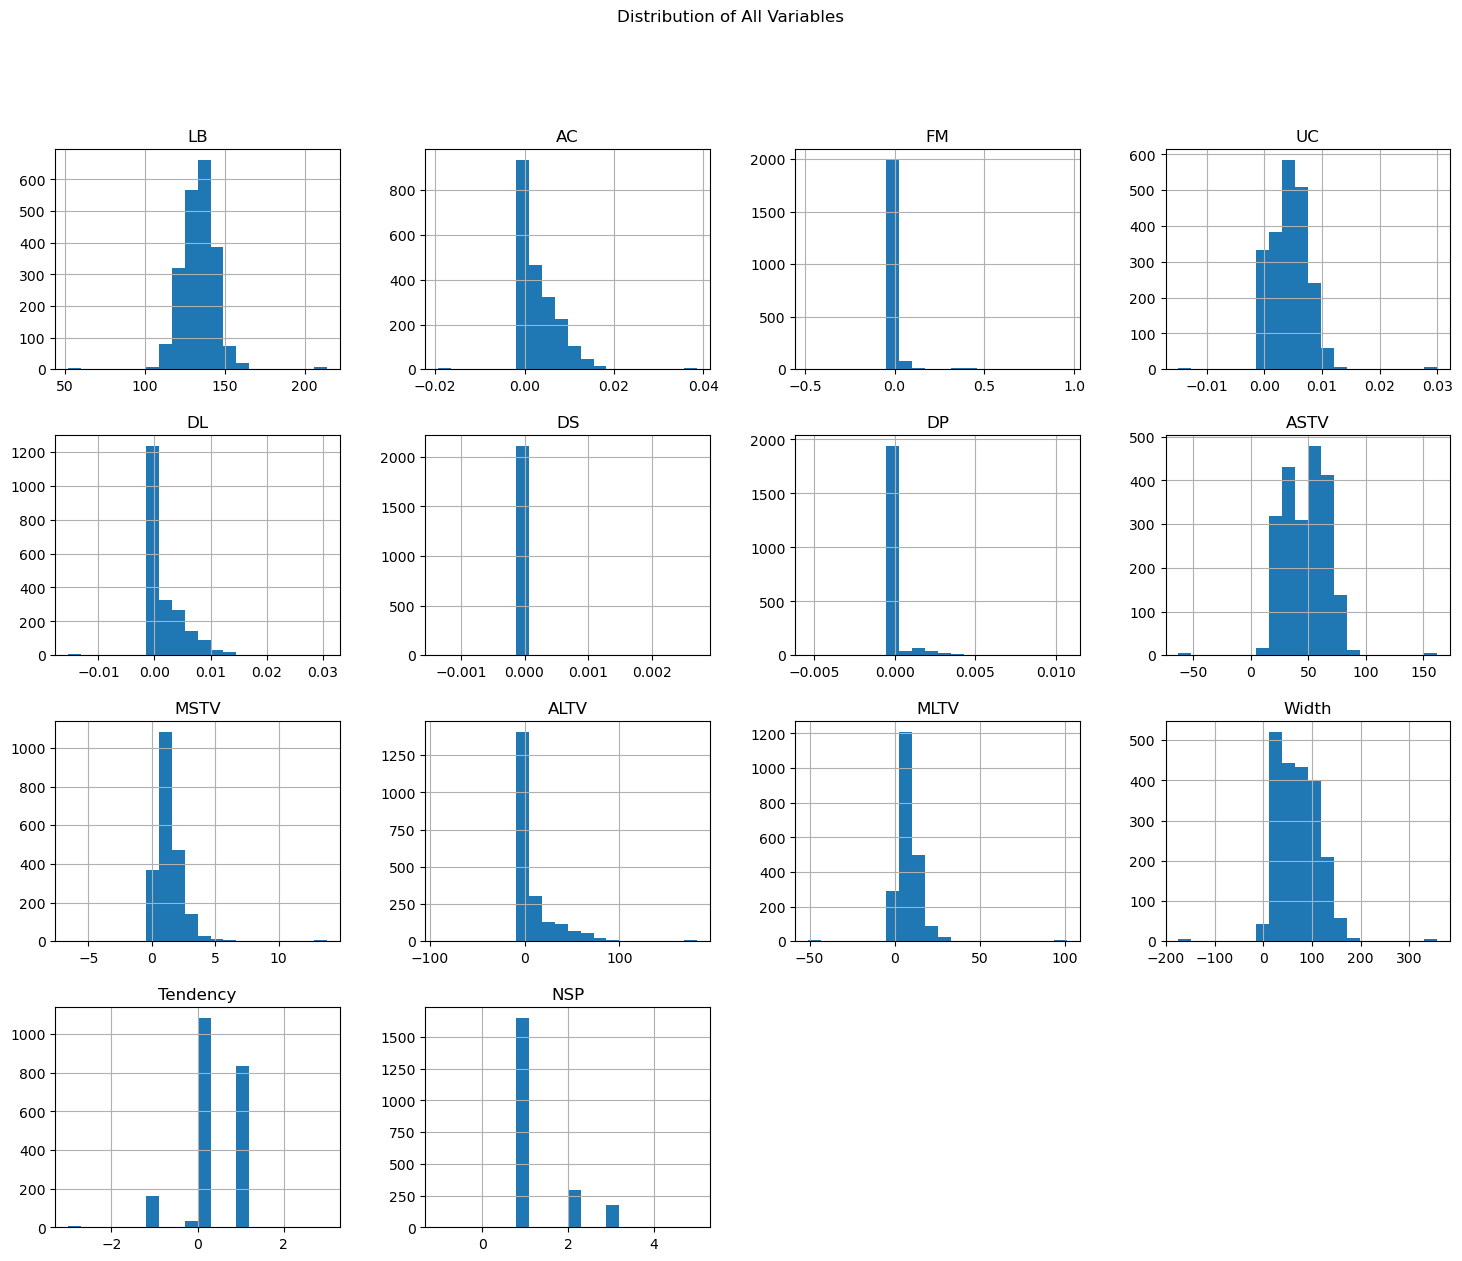

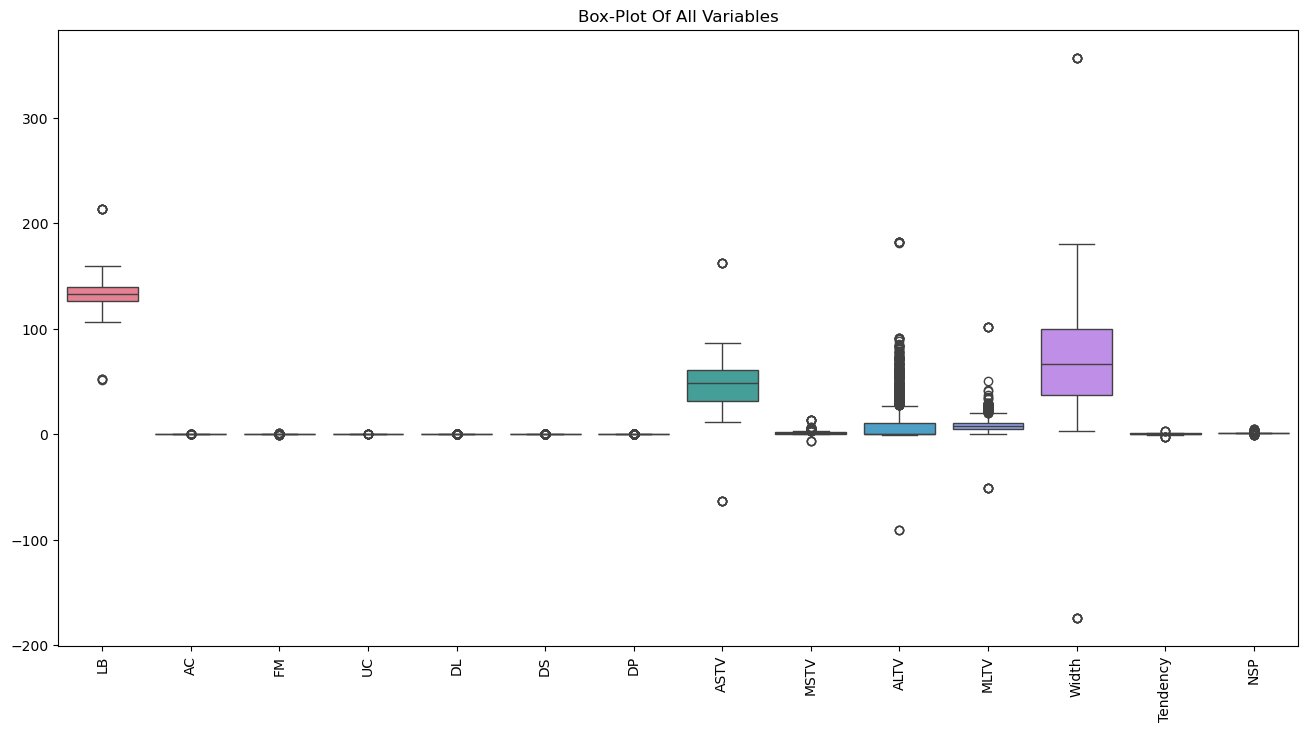

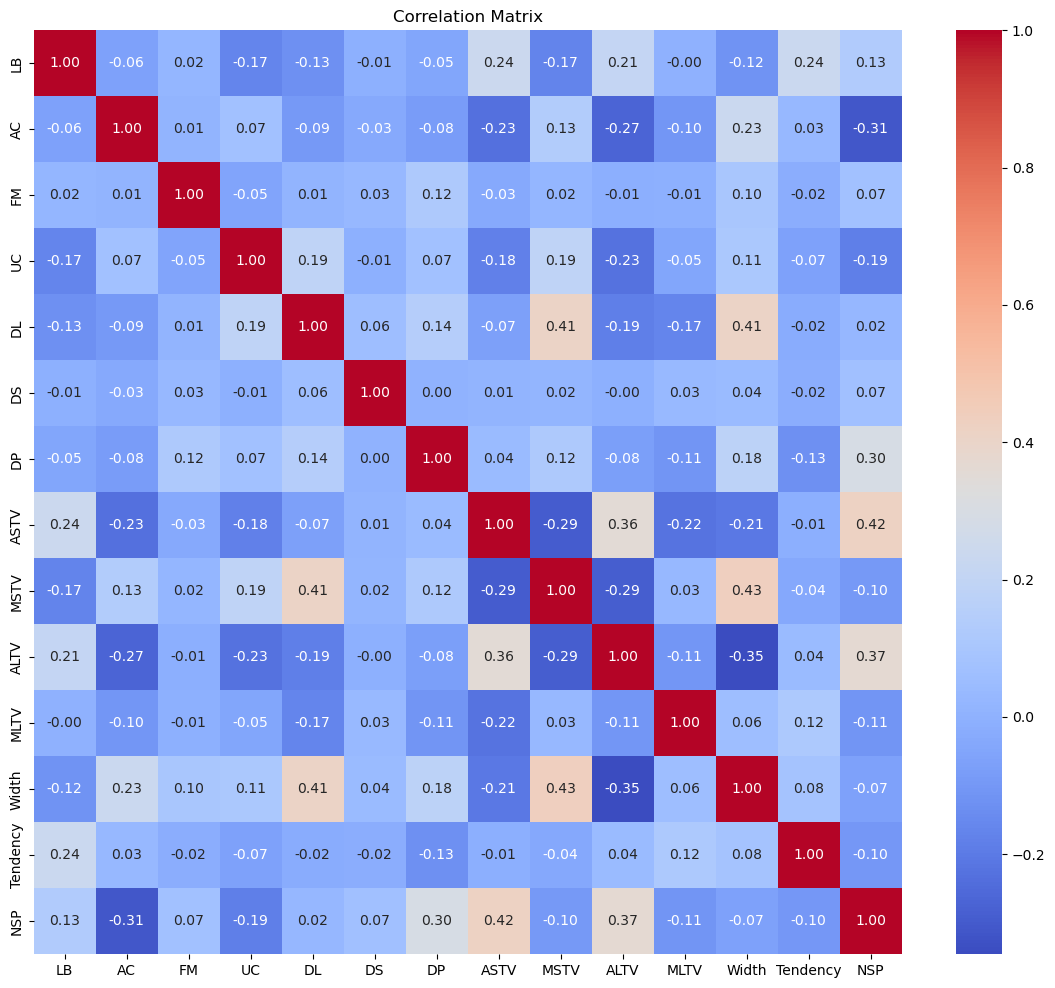

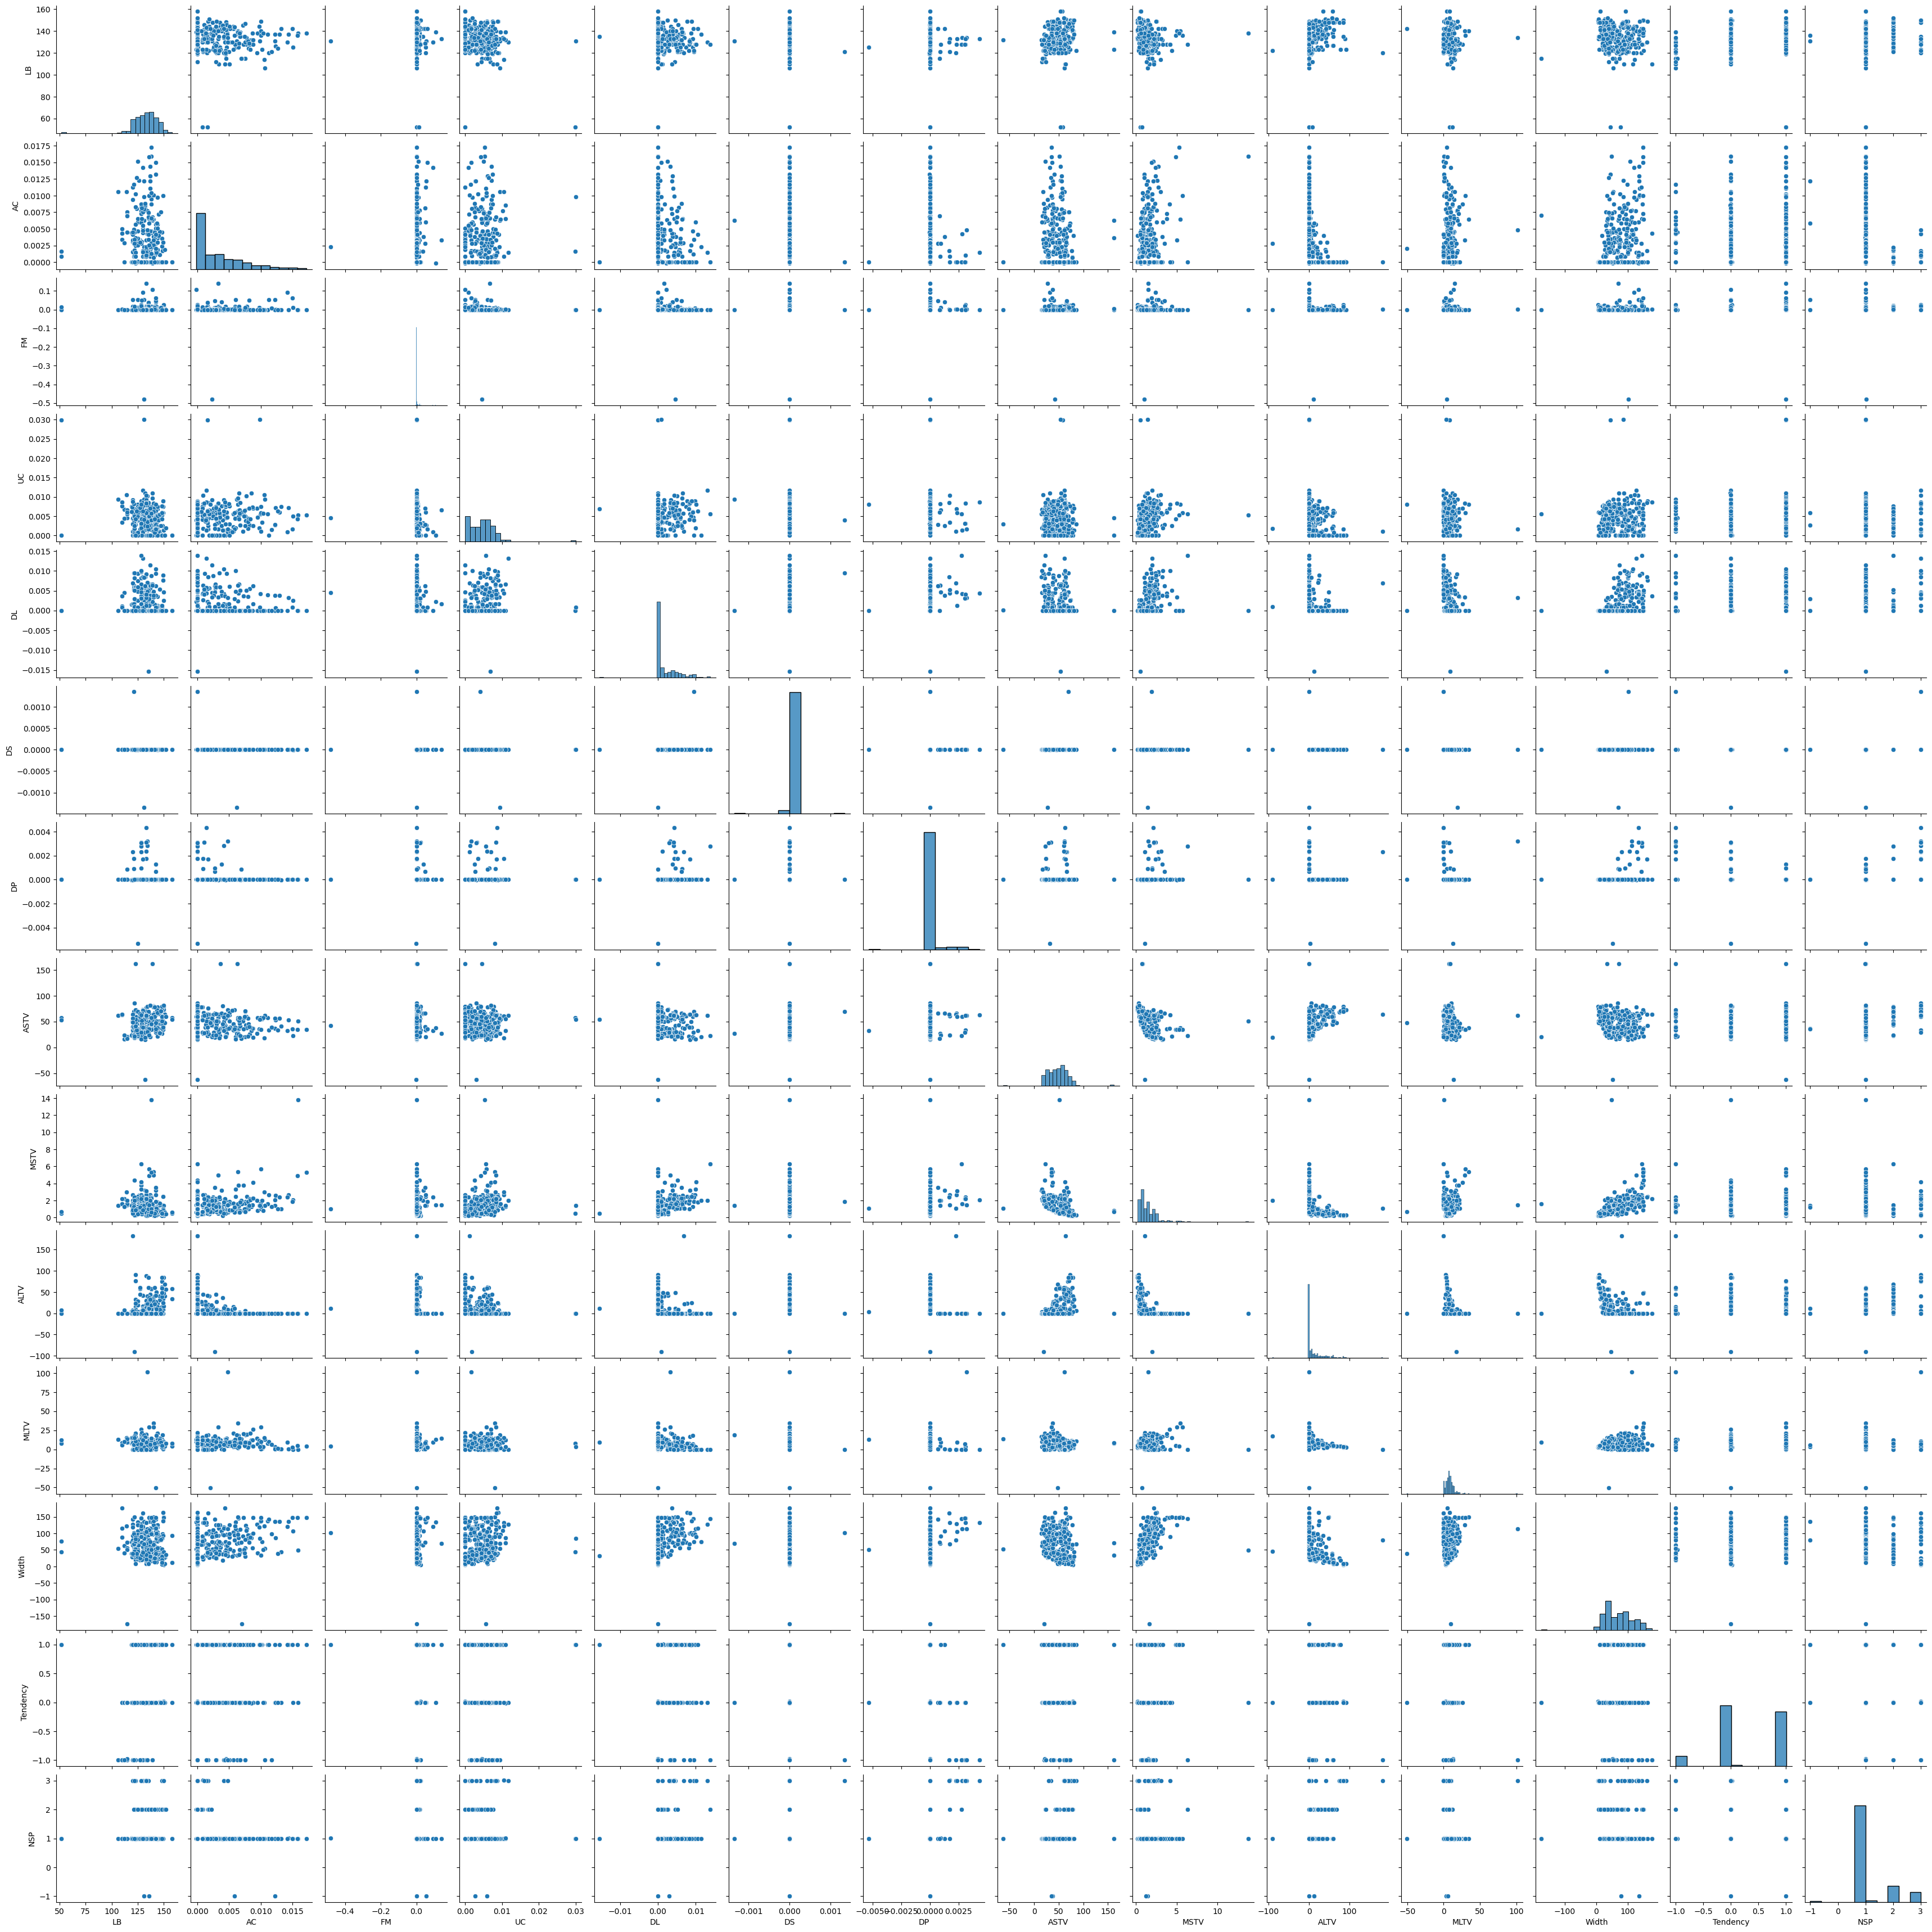

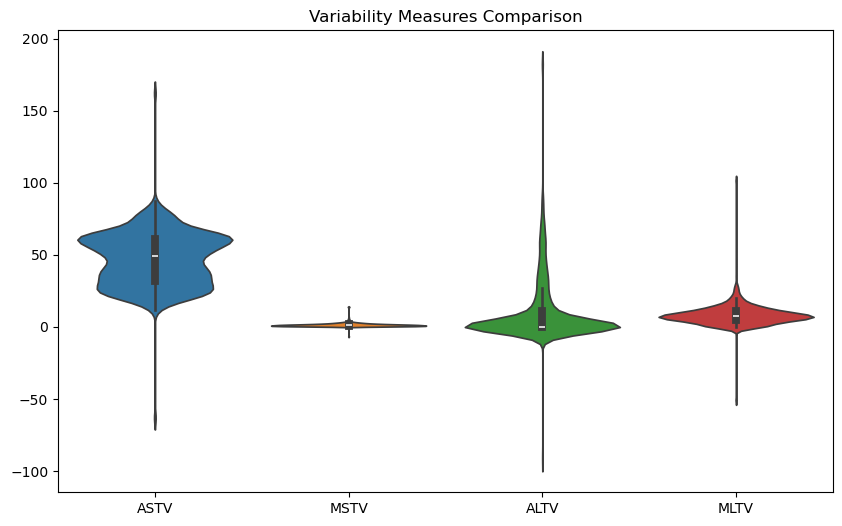

Original Shape: (2126, 14)
After Removing Outliers: (896, 14)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv(r"C:\Users\NIKHIL\Downloads\data science assignment\data science assignment\Cardiotocographic.csv")

df.info()

df.describe()

df.shape

df.columns

df.isnull()

df.isnull().sum()

df=df.fillna(df.median(numeric_only=True))

df.describe().T

summary=pd.DataFrame({
    "Mean :" : df.mean(),
    "Median :" : df.mean(),
    "Std Dev :" : df.std(),
    "IQR :" : df.quantile(0.75)-df.quantile(0.25)
    })
print(summary)

df.hist(figsize=(18,14), bins=20)
plt.suptitle("Distribution of All Variables")
plt.show()

plt.figure(figsize=(16,8))
sns.boxplot(data=df)
plt.title("Box-Plot Of All Variables")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(14,12))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

sns.pairplot(df.sample(300))
plt.show()

plt.figure(figsize=(10,6))
sns.violinplot(data=df[["ASTV","MSTV","ALTV","MLTV"]])
plt.title("Variability Measures Comparison")
plt.show()

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_no_outliers = df[~((df < (Q1 - 1.5 * IQR)) |
                      (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print("Original Shape:", df.shape)
print("After Removing Outliers:", df_no_outliers.shape)

df.corr()["NSP"].sort_values(ascending=False)

df.to_csv("cardiotocographic_cleaned.csv", index=False)
